In [1]:
import scipy
import matplotlib.pyplot as plt
from dataclasses import dataclass
import numpy
import itertools
import pandas

# Set-up

In [2]:
@dataclass(frozen=True)
class InfectionConfig:
    """All the conigures of the infection rate"""
    Infectivity : float = 0.6 
    ContactRateInfectious : float = 1.25
    AvgIncubationTime : float = 10  
    AvgIllnessDur : float = 15
    TotalPopulation : float = 10e3 


def f_SolveInfection(t, vals, IConfig : InfectionConfig):
    Susceptible, Exposed, Infectious, Recovered = vals

    dtExposedRate =  IConfig.ContactRateInfectious * Infectious * IConfig.Infectivity * Susceptible / IConfig.TotalPopulation
    dtInfectiosRate = Exposed / IConfig.AvgIncubationTime 
    dtRecovered = Infectious / IConfig.AvgIllnessDur
    
    dSuscpetible = -dtExposedRate
    dExposed = dtExposedRate - dtInfectiosRate
    dInfectious = dtInfectiosRate - dtRecovered
    dRecovered = dtRecovered
    
    return [dSuscpetible, dExposed, dInfectious, dRecovered]


labels = ["Susceptible", "Exposed", "Infectious", "Recovered"]
colors = ["blue", "orange", "red", "green"]


# Run

In [3]:
tspan = numpy.linspace(0,150,1000)
IConfig = InfectionConfig()

#     Susceptible,                  Exposed,   Infectious,  Recovered
y0 = [IConfig.TotalPopulation-1,    0,         1,           0          ]


Results = scipy.integrate.solve_ivp(f_SolveInfection, (tspan[0], tspan[-1]), y0, args=(IConfig,) , t_eval=tspan)

# Plot

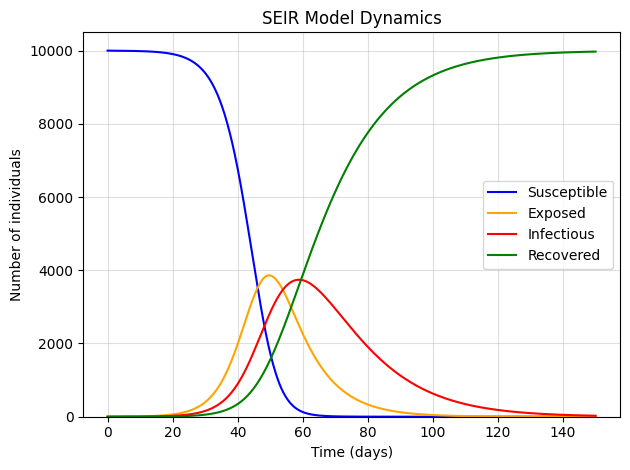

In [4]:
for i, (l,c) in enumerate(zip(labels, colors)):
    plt.plot(Results.t, Results.y[i], label=l, color=c)

plt.legend()
plt.ylabel("Number of individuals")
plt.xlabel("Time (days)")
plt.title("SEIR Model Dynamics")
plt.grid(alpha=0.4)
plt.tight_layout() # dam plotting without this thing
plt.ylim(bottom=-0.1)
plt.savefig("Figures//SEIR-Python.png")
plt.show()

# Parameter variation experiment

In [5]:
infection_rate_range = numpy.arange(0.3, 2, 0.25)
contact_rate_range = numpy.arange(0.2, 5, 0.4)

iconfig_vals = [ InfectionConfig(Infectivity=infect_rate, ContactRateInfectious=contact_rate) 
                  for infect_rate, contact_rate in itertools.product(infection_rate_range, contact_rate_range)
                ] # itertools products should not used with a single range val. Otherwise a tuple is returned instead of an integer/string data type

Results = [scipy.integrate.solve_ivp(f_SolveInfection, 
                                     (tspan[0], tspan[-1]),
                                     y0, 
                                    args=(config_i,), 
                                    t_eval=tspan)  
            for config_i in iconfig_vals]

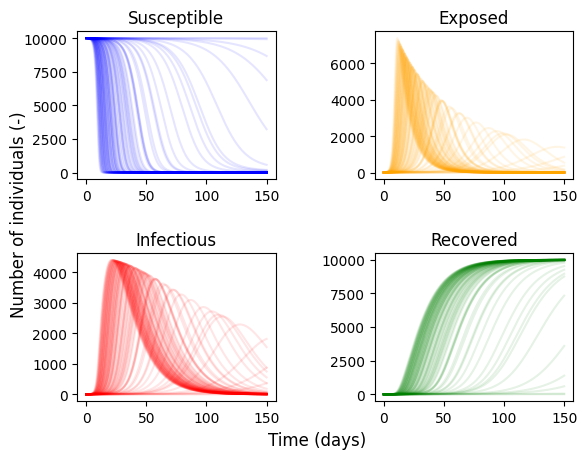

In [6]:
fig, axes  = plt.subplots(2,2)

fig.supxlabel("Time (days)")
fig.supylabel("Number of individuals (-)")
fig.subplots_adjust(hspace=0.5, wspace=0.5)

alpha_range = numpy.linspace(0.1, 1, len(Results))

for (i, (ax, l)) in enumerate(zip(axes.ravel(), labels)):
    ax.set_title(l)


    for a_ii, r_ii in zip(alpha_range, Results):
        alpha_range
        
        ax.plot(r_ii.t, r_ii.y[i], color=colors[i], alpha=0.1)

# Parameter fitting

In [21]:
def solve_infectiousRate(params, IConfig : InfectionConfig, TargetData : pandas.DataFrame):
    # Get the values
    guesse_infectiousRate, guesse_Infectivity = params

    # set the config
    IConfig = InfectionConfig(ContactRateInfectious=guesse_infectiousRate,
                              Infectivity=guesse_Infectivity)
    
    # set Init vals     Susceptible,                  Exposed,   Infectious,  Recovered
    y0 = [IConfig.TotalPopulation-1,    0,         1,           0          ]

    
    Results = scipy.integrate.solve_ivp(f_SolveInfection, 
                                        (TargetData["Time(days)"].min(), TargetData["Time(days)"].max()), 
                                        y0, 
                                        args=(IConfig,), 
                                        t_eval=TargetData["Time(days)"].values)

    val = ((numpy.abs(TargetData["Infected"].values - Results.y[2]))**2).sum()
    return val**

SyntaxError: invalid syntax (3890655537.py, line 20)

In [8]:
df_hisotoc = pandas.read_csv("HistoricData.txt", sep='\t', names=["Time(days)", "Infected"])

In [9]:
soln = scipy.optimize.minimize(solve_infectiousRate, [0.7, 0.7], args=(InfectionConfig, df_hisotoc), bounds=[(0.01,2), (0.01,2)])
soln

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 860.7845674978812
        x: [ 8.724e-01  8.724e-01]
      nit: 9
      jac: [-1.955e-01 -2.639e-01]
     nfev: 141
     njev: 47
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

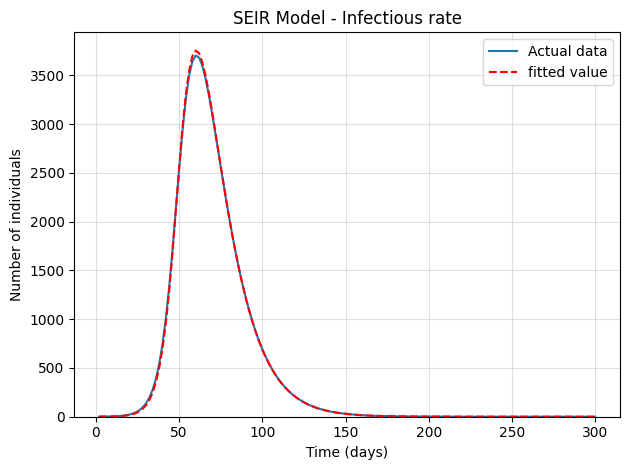

In [19]:
plt_rlt = scipy.integrate.solve_ivp(f_SolveInfection, (df_hisotoc["Time(days)"].min(), df_hisotoc["Time(days)"].max()), y0, args=(InfectionConfig(Infectivity = soln.x[0], ContactRateInfectious = soln.x[1]),) , t_eval=df_hisotoc["Time(days)"])


plt.plot(df_hisotoc["Time(days)"], df_hisotoc["Infected"], label="Actual data")
plt.plot(plt_rlt.t, plt_rlt.y[2], '--r', label="fitted value")
plt.legend()
plt.ylabel("Number of individuals")
plt.xlabel("Time (days)")
plt.title("SEIR Model - Infectious rate")
plt.grid(alpha=0.4)
plt.tight_layout() # dam plotting without this thing
plt.ylim(bottom=-0.1)
plt.savefig("Figures//SEIR-Python.png")
plt.show()